In [249]:
import os 
import numpy as np 
import pandas as pd
import scanpy as sc
from matplotlib import rcParams

FIGSIZE = (3, 3)
rcParams["figure.figsize"] = FIGSIZE

In [228]:
adata_pbmc68k = sc.read_h5ad("../../project_folder/data/pbmc68k.h5ad")

Dataset is raw!

In [229]:
adata_pbmc68k.X.A.max(1)

array([5., 5., 5., ..., 6., 5., 4.], dtype=float32)

In [230]:
adata_pbmc68k.layers["X_counts"] = adata_pbmc68k.X.copy()

In [231]:
sc.pp.highly_variable_genes(adata_pbmc68k,
                            flavor='seurat_v3', 
                            n_top_genes=3000)

In [232]:
adata_pbmc68k = adata_pbmc68k[:, adata_pbmc68k.var.highly_variable]

# Normalize plus Leiden

In [233]:
sc.pp.normalize_total(adata_pbmc68k)
sc.pp.log1p(adata_pbmc68k)
sc.tl.pca(adata_pbmc68k)
sc.pp.neighbors(adata_pbmc68k)
sc.tl.umap(adata_pbmc68k)

/home/icb/alessandro.palma/miniconda3/envs/celldreamer/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:208: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/home/icb/alessandro.palma/miniconda3/envs/celldreamer/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:235: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))


In [234]:
sc.tl.leiden(adata_pbmc68k, resolution=0.4)

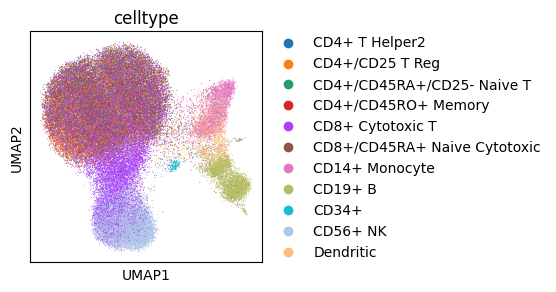

In [235]:
sc.pl.umap(adata_pbmc68k, color="celltype")

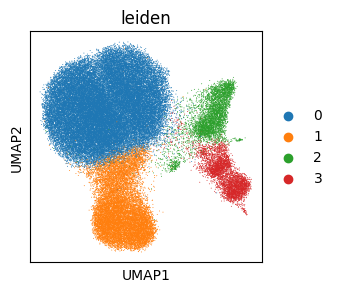

In [236]:
sc.pl.umap(adata_pbmc68k, color="leiden")

Now we proceed with the assignment: 
* The clusters represent cell states
* The individuals represent treatments 

leiden         0      1     2     3
treatment                          
0          21399    721  4369  2155
1          21261  13645   225  2102


/home/icb/alessandro.palma/miniconda3/envs/celldreamer/lib/python3.10/site-packages/scanpy/plotting/_utils.py:491: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


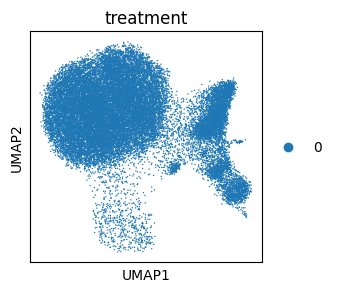

/home/icb/alessandro.palma/miniconda3/envs/celldreamer/lib/python3.10/site-packages/scanpy/plotting/_utils.py:491: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


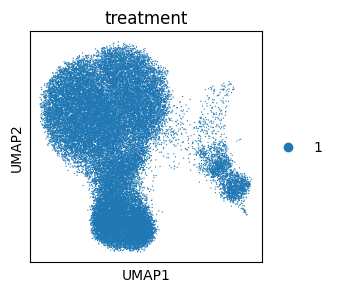

leiden         0      1     2     3
treatment                          
0          21304   1506  4157  2199
1          21356  12860   437  2058


/home/icb/alessandro.palma/miniconda3/envs/celldreamer/lib/python3.10/site-packages/scanpy/plotting/_utils.py:491: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


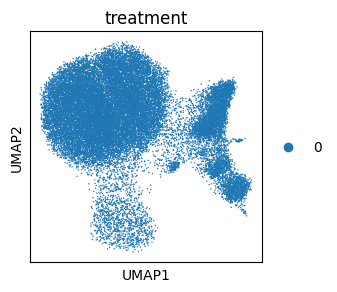

/home/icb/alessandro.palma/miniconda3/envs/celldreamer/lib/python3.10/site-packages/scanpy/plotting/_utils.py:491: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


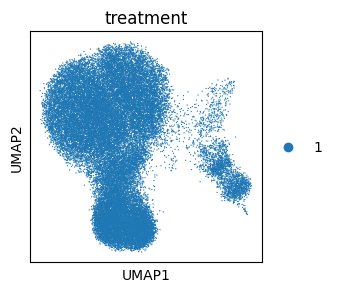

leiden         0      1     2     3
treatment                          
0          21148   2876  3631  2102
1          21512  11490   963  2155


/home/icb/alessandro.palma/miniconda3/envs/celldreamer/lib/python3.10/site-packages/scanpy/plotting/_utils.py:491: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


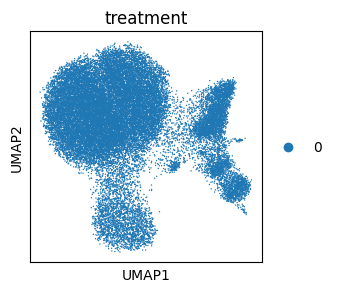

/home/icb/alessandro.palma/miniconda3/envs/celldreamer/lib/python3.10/site-packages/scanpy/plotting/_utils.py:491: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


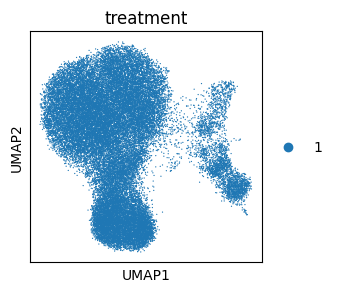

leiden         0      1     2     3
treatment                          
0          21358   4289  3210  2158
1          21302  10077  1384  2099


/home/icb/alessandro.palma/miniconda3/envs/celldreamer/lib/python3.10/site-packages/scanpy/plotting/_utils.py:491: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


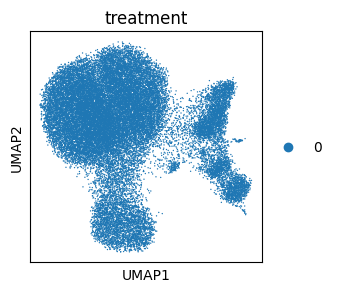

/home/icb/alessandro.palma/miniconda3/envs/celldreamer/lib/python3.10/site-packages/scanpy/plotting/_utils.py:491: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


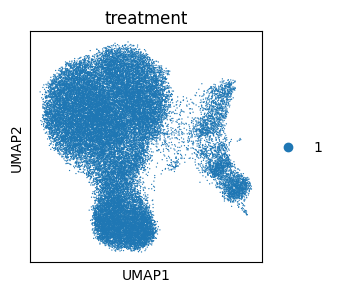

leiden         0     1     2     3
treatment                         
0          21366  5753  2759  2099
1          21294  8613  1835  2158


/home/icb/alessandro.palma/miniconda3/envs/celldreamer/lib/python3.10/site-packages/scanpy/plotting/_utils.py:491: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


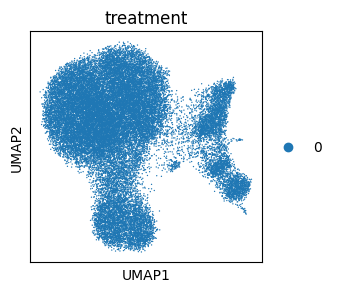

/home/icb/alessandro.palma/miniconda3/envs/celldreamer/lib/python3.10/site-packages/scanpy/plotting/_utils.py:491: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


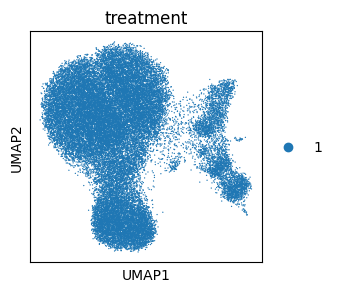

leiden         0     1     2     3
treatment                         
0          21249  6502  2597  2122
1          21411  7864  1997  2135


/home/icb/alessandro.palma/miniconda3/envs/celldreamer/lib/python3.10/site-packages/scanpy/plotting/_utils.py:491: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


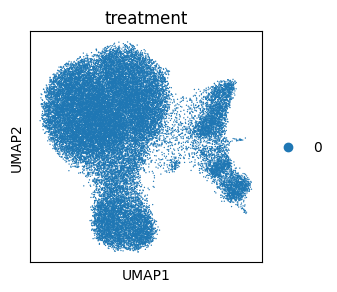

/home/icb/alessandro.palma/miniconda3/envs/celldreamer/lib/python3.10/site-packages/scanpy/plotting/_utils.py:491: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


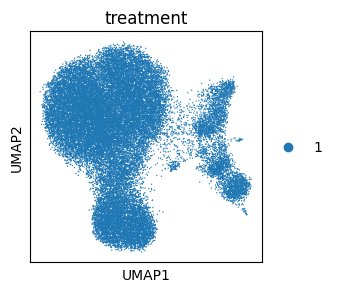

In [243]:
np.random.seed(42)
N = adata_pbmc68k.shape[0]

rates = (adata_pbmc68k.obs.leiden.value_counts() / adata_pbmc68k.shape[0]).values
depletion_rates = 0.5 - np.array([0.05, 0.1, 0.2, 0.3, 0.4, 0.45])

for depletion_rate in depletion_rates:
    # Initialize treatment column 
    adata_pbmc68k_tmp =  adata_pbmc68k.copy()
    adata_pbmc68k_tmp.obs["treatment"] = None 

    # Alter treatment representation per cluster
    treatment_rates_per_cluster = np.array([[0.5, 0.5]]*4)
    treatment_rates_per_cluster[1, 0] = treatment_rates_per_cluster[1, 0] - depletion_rate
    treatment_rates_per_cluster[1, 1] = treatment_rates_per_cluster[1, 1] + depletion_rate
    treatment_rates_per_cluster[2, 0] = treatment_rates_per_cluster[2, 0] + depletion_rate
    treatment_rates_per_cluster[2, 1] = treatment_rates_per_cluster[2, 1] - depletion_rate

    # Assign treatment rates for every cell 
    rates_per_obs = treatment_rates_per_cluster[adata_pbmc68k.obs.leiden.astype(int), :]
    
    treatment_label = []
    for r in rates_per_obs:
        treatment_label.append(np.random.choice([0, 1], p=r))

    adata_pbmc68k_tmp.obs["treatment"] = treatment_label
    adata_pbmc68k_tmp.obs["treatment"] = adata_pbmc68k_tmp.obs["treatment"].astype("category")
    print(pd.crosstab(adata_pbmc68k_tmp.obs.treatment, adata_pbmc68k_tmp.obs.leiden))
    sc.pl.umap(adata_pbmc68k_tmp[adata_pbmc68k_tmp.obs.treatment==0], color="treatment")
    sc.pl.umap(adata_pbmc68k_tmp[adata_pbmc68k_tmp.obs.treatment==1], color="treatment")

    # Save data 
    depletion_rate = np.round(depletion_rate, 3)
    adata_pbmc68k_tmp.write_h5ad(f"../../project_folder/data/pbmc68k_oversampled/pbmc68k_{depletion_rate}.h5ad")